<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/EEG_Primary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Sel instalasi dependensi
%pip -q install "decorator>=4.0.2,<5.0" "mne==1.6.1" "jedi>=0.16" "PyWavelets>=1.4" "h5py>=3.8" "joblib>=1.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 1 — KONFIGURASI & IMPORT
# ============================================================
from google.colab import drive
from pathlib import Path
import json, re, warnings, h5py, joblib, mne, pywt, decorator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import ipywidgets as widgets
from math import gcd
from hashlib import sha1
from IPython.display import display, clear_output
from scipy.signal import butter, detrend, resample_poly, sosfiltfilt, welch
from scipy.stats import entropy
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV, GroupKFold, LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

if not Path("/content/drive/MyDrive").exists(): drive.mount("/content/drive")
warnings.filterwarnings("ignore"); mne.set_log_level("ERROR")

BASE_DIR = Path("/content/drive/MyDrive/Creativity-Dataset/")
SECONDARY_DIR, PRIMARY_RAW_DIR, PRIMARY_MERGED_DIR = BASE_DIR/"Secondary", BASE_DIR/"Primary-raw", BASE_DIR/"Primary-merged"
PRIMARY_SEGMENTS_CSV, CACHE_DIR = BASE_DIR/"primary_segments.csv", BASE_DIR/"cache"
PREPROCESSED_CACHE_DIR, FEATURE_CACHE_DIR, OUTPUT_DIR = CACHE_DIR/"preprocessed", CACHE_DIR/"features", BASE_DIR/"output"
for folder in [SECONDARY_DIR, PRIMARY_RAW_DIR, PRIMARY_MERGED_DIR, PREPROCESSED_CACHE_DIR, FEATURE_CACHE_DIR, OUTPUT_DIR]: folder.mkdir(parents=True, exist_ok=True)

FS_PRIMARY, FS_SECONDARY, FS_TARGET = 125, 500, 125
BANDPASS_LOW, BANDPASS_HIGH, FILTER_ORDER = 1.0, 40.0, 4
KNOWN_RAIL_ABS_THRESHOLD, ROBUST_OUTLIER_MAD_MULTIPLIER = 180000.0, 25.0
MAX_REPAIR_RATIO_PER_CHANNEL, BAD_CHANNEL_Z_THRESHOLD, EPOCH_ARTIFACT_Z_THRESHOLD = 0.05, 5.0, 5.0
WAVELET, DWT_LEVEL, ADD_SPECTRAL_FEATURES = "db4", 5, True
MAX_EPOCHS_PER_SUBJECT_CLASS, DEBUG_MAX_SUBJECTS = 180, 2
CACHE_VERSION, FORCE_REBUILD_FEATURES, RANDOM_STATE = "v3_streaming_16ch_1to40hz_125hz", False, 42
EXPERIMENT_CONFIGS = [{"epoch_seconds": 2.0, "overlap_ratio": 0.0, "primary_trim_seconds": 0.0},{"epoch_seconds": 2.0, "overlap_ratio": 0.5, "primary_trim_seconds": 2.0},{"epoch_seconds": 4.0, "overlap_ratio": 0.5, "primary_trim_seconds": 2.0}]

# Pilihan:
# "secondary"
# "primary"
# "combined"
DATASET_MODE = "primary"

# Pilihan:
# "separate"
# "merged"
PRIMARY_INPUT_MODE = "separate"

MANUAL_SELECTED_FILES = []
print("Environment Ready")

Environment Ready


In [ ]:
# ============================================================
# LABEL & KANAL
# ============================================================

LABELS = ["RST1", "IDG", "IDE", "IDR", "RST2"]
PRIMARY_CHANNELS_ORIGINAL = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T3", "T4", "T5", "T6", "P3", "P4", "O1", "O2"]
CANONICAL_CHANNELS = ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "C3", "C4", "T7", "T8", "P7", "P8", "P3", "P4", "O1", "O2"]

SECONDARY_CHANNELS_64 = [
    "Fp1", "Fp2", "Fpz", "AF3", "AF4", "AF7", "AF8", "AFz", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "Fz",
    "FT7", "FT8", "FC1", "FC2", "FC3", "FC4", "FC5", "FC6", "FCz", "T7", "T8", "C1", "C2", "C3", "C4", "C5", "C6", "Cz",
    "TP7", "TP8", "CP1", "CP2", "CP3", "CP4", "CP5", "CP6", "CPz", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8",
    "P9", "P10", "Pz", "PO3", "PO4", "PO7", "PO8", "POz", "O1", "O2", "Oz", "Iz"
]

SECONDARY_CHANNELS_63 = [ch for ch in SECONDARY_CHANNELS_64 if ch != "Cz"]
SECONDARY_SELECTED_INDICES = [SECONDARY_CHANNELS_63.index(ch) for ch in CANONICAL_CHANNELS]

def normalize_label(text):
    text = str(text).upper()
    for label in LABELS:
        if label in text: return label
    return None

def infer_subject_id(text, prefix):
    match = re.search(r"SUB(?:JECT)?[_\-\s]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match: raise ValueError(f"Nomor subjek tidak ditemukan: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

channel_mapping_df = pd.DataFrame({"kanal_primer": PRIMARY_CHANNELS_ORIGINAL, "kanal_harmonisasi": CANONICAL_CHANNELS, "idx_sekunder": SECONDARY_SELECTED_INDICES})
display(channel_mapping_df)
print("Index 16 kanal sekunder:", SECONDARY_SELECTED_INDICES)

,kanal_primer,kanal_harmonisasi,idx_sekunder
0,Fp1,Fp1,0
1,Fp2,Fp2,1
2,F3,F3,10
3,F4,F4,11
4,F7,F7,14
5,F8,F8,15
6,C3,C3,30
7,C4,C4,31
8,T3,T7,26
9,T4,T8,27


Index 16 kanal sekunder: [0, 1, 10, 11, 14, 15, 30, 31, 26, 27, 49, 50, 45, 46, 59, 60]


In [ ]:
import re
from pathlib import Path
import scipy.io as sio
import h5py
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from hashlib import sha1

# --- HELPER FUNCTIONS ---
def normalize_label(text):
    text = str(text).upper()
    for label in LABELS:
        if label in text: return label
    return None

def infer_subject_id(text, prefix):
    # Mencari pola 'Sub' diikuti oleh karakter apa pun (opsional) lalu angka
    match = re.search(r"Sub[^0-9]*(\d+)", str(text), flags=re.IGNORECASE)
    if not match:
        # Jika tidak ada kata 'Sub', ambil urutan angka pertama yang ditemukan
        match = re.search(r"(\d+)", str(text))

    if not match: raise ValueError(f"Nomor subjek tidak ditemukan pada: {text}")
    return f"{prefix}_{int(match.group(1)):03d}"

def stable_name(text):
    return sha1(str(text).encode("utf-8")).hexdigest()[:16]

def natural_sort_key(path):
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r'(\d+)', str(path))]

def list_mat_variables(file_path):
    file_path = Path(file_path)
    try: return [(name, tuple(shape), dtype) for name, shape, dtype in sio.whosmat(file_path)]
    except (NotImplementedError, ValueError, OSError):
        results = []
        with h5py.File(file_path, 'r') as handle:
            def visitor(name, obj):
                if isinstance(obj, h5py.Dataset): results.append((name, tuple(obj.shape), str(obj.dtype)))
            handle.visititems(visitor)
        return results

def load_mat_variable(file_path, key):
    file_path = Path(file_path)
    try:
        mat_dictionary = sio.loadmat(file_path, variable_names=[key])
        if key not in mat_dictionary: raise KeyError(f'Key {key} not found')
        return np.asarray(mat_dictionary[key])
    except:
        with h5py.File(file_path, 'r') as handle: return np.asarray(handle[key])

def choose_primary_key(file_path):
    vars = list_mat_variables(file_path)
    cands = [(int(np.prod(s)), n) for n, s, _ in vars if len(s) == 2]
    if not cands: raise ValueError(f'No 2D array in {file_path}')
    avail_vars = [n for _, n in cands]
    return 'data' if 'data' in avail_vars else max(cands, key=lambda x: x[0])[1]

def counter_quality(counter):
    c = np.asarray(counter, dtype=float)
    if len(c) < 2: return {'dominant_step': np.nan, 'normal_step_ratio': 0, 'duplicate_count': 0, 'jump_count': 0}
    df = np.mod(np.diff(c), 256); v, ct = np.unique(df, return_counts=True); dom = float(v[np.argmax(ct)])
    return {'dominant_step': dom, 'normal_step_ratio': float((df == dom).mean()), 'duplicate_count': int((df == 0).sum()), 'jump_count': int(((df != dom) & (df != 0)).sum())}

def looks_like_packet_counter(col):
    col = np.asarray(col, dtype=float)
    if len(col) < 2 or not np.isfinite(col).all(): return False
    q = counter_quality(col)
    return np.mean(np.isclose(col, np.round(col))) > 0.99 and q['dominant_step'] in {1.0, 2.0} and q['normal_step_ratio'] > 0.80

def extract_primary_eeg(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.shape[1] in {16, 17}: d = arr
    elif arr.shape[0] in {16, 17}: d = arr.T
    else: raise ValueError(f'Invalid shape: {arr.shape}')
    if d.shape[1] == 17:
        if not looks_like_packet_counter(d[:, 0]): raise ValueError('Invalid packet counter')
        return d[:, 1:17].T, counter_quality(d[:, 0])
    return d[:, :16].T, None

def detect_file_source(path):
    f = Path(path).resolve()
    if f.is_relative_to(SECONDARY_DIR.resolve()): return 'secondary'
    if f.is_relative_to(PRIMARY_RAW_DIR.resolve()): return 'primary_raw'
    if f.is_relative_to(PRIMARY_MERGED_DIR.resolve()): return 'primary_merged'
    raise ValueError(f'Unknown source: {path}')

def load_record_eeg(ref):
    arr = load_mat_variable(ref['file_path'], ref['mat_key'])
    if ref['source'] == 'secondary':
        eeg = arr if arr.shape[0] == 63 else arr.T
        return eeg[SECONDARY_SELECTED_INDICES, :].astype(float), None
    eeg, log = extract_primary_eeg(arr)
    return eeg.astype(float), log

def get_all_available_files():
    sec = sorted(SECONDARY_DIR.rglob('*.mat'), key=natural_sort_key)
    pri_raw = sorted(PRIMARY_RAW_DIR.rglob('*.mat'), key=natural_sort_key)
    pri_merged = sorted(PRIMARY_MERGED_DIR.rglob('*.mat'), key=natural_sort_key)
    if DATASET_MODE == 'secondary': return sec
    if DATASET_MODE == 'primary': return pri_merged if PRIMARY_INPUT_MODE == 'merged' else pri_raw
    return sec + pri_merged + pri_raw

def discover_selected_refs(paths):
    res = []
    for p in paths:
        f = Path(p); src_type = detect_file_source(f)
        source = 'secondary' if src_type == 'secondary' else 'primary'
        sid = infer_subject_id(f.stem, 'SEC' if source == 'secondary' else 'PRI')

        if source == 'secondary' or src_type == 'primary_merged':
            for k, s, _ in list_mat_variables(f):
                lbl = normalize_label(k)
                if lbl:
                    if source == 'secondary' and 63 in s:
                        res.append({'source': source, 'subject_id': sid, 'record_id': f'{sid}__{k}', 'label': lbl, 'file_path': str(f), 'mat_key': k, 'sfreq': FS_SECONDARY})
                    elif source == 'primary':
                        res.append({'source': source, 'subject_id': sid, 'record_id': f'{sid}__{k}', 'label': lbl, 'file_path': str(f), 'mat_key': k, 'sfreq': FS_PRIMARY})
        else:
            if lbl := normalize_label(f.stem):
                res.append({'source': source, 'subject_id': sid, 'record_id': f'{sid}__{f.stem}', 'label': lbl, 'file_path': str(f), 'mat_key': choose_primary_key(f), 'sfreq': FS_PRIMARY})
    return res

def validate_selected_refs(refs):
    if not refs: raise ValueError('No records found.')
    df = pd.DataFrame(refs); srcs = set(df['source'])
    if DATASET_MODE == 'secondary' and srcs != {'secondary'}: raise ValueError('Mode secondary requires secondary files only.')
    if DATASET_MODE == 'primary' and srcs != {'primary'}: raise ValueError('Mode primary requires primary files only.')
    cnt = df.groupby(['source', 'subject_id', 'label']).size().reset_index(name='count')
    display(cnt)
    print('Validation success.')
    return df, cnt

def on_process_clicked(b):
    with output_area:
        clear_output()
        if not file_selector.value: print('Pilih file dulu.'); return
        try:
            global refs, refs_df, record_count_df, MANUAL_SELECTED_FILES
            refs = discover_selected_refs(file_selector.value)
            refs_df, record_count_df = validate_selected_refs(refs)
            MANUAL_SELECTED_FILES = list(file_selector.value)
            print(f'Siap: {len(refs)} record terdeteksi.')
        except Exception as e: print(f'Gagal: {e}')

avail_files = get_all_available_files()
opts_data = [(f'[{detect_file_source(f).upper()}] {f.parent.name}/{f.name}', str(f)) for f in avail_files]
file_selector = widgets.SelectMultiple(options=opts_data, layout={'width': '100%', 'height': '280px'})
btn_proc = widgets.Button(description='Proses File Terpilih', button_style='success')
output_area = widgets.Output()
btn_proc.on_click(on_process_clicked)
display(widgets.VBox([widgets.HTML('<b>Pilih file MAT (Ctrl+Klik):</b>'), file_selector, btn_proc, output_area]))

In [ ]:
# ============================================================
# PREPROCESSING UTILS & CACHE
# ============================================================
def robust_zscore(v):
    v = np.asarray(v, dtype=float)
    if v.size == 0: return v
    med = np.nanmedian(v)
    mad = np.nanmedian(np.abs(v - med))
    return 0.6745 * (v - med) / (mad + 1e-12) if mad > 1e-12 else np.zeros_like(v)

def interpolate_invalid_1d(sig, mask):
    return pd.Series(sig).mask(mask).interpolate(limit_direction="both").bfill().ffill().values

def repair_primary_invalid_samples(eeg):
    eeg, logs = eeg.copy(), []
    for i, ch in enumerate(CANONICAL_CHANNELS):
        sig, fin = eeg[i], eeg[i][np.isfinite(eeg[i])]
        if fin.size == 0:
            mask = np.ones_like(sig, dtype=bool)
        else:
            med = np.median(fin)
            mad = np.median(np.abs(fin-med))
            scale = 1.4826 * mad if mad > 1e-12 else (np.std(fin) + 1e-12)
            mask = ~np.isfinite(sig) | (np.abs(sig) >= KNOWN_RAIL_ABS_THRESHOLD)
            mask |= (np.abs(sig - med) > (ROBUST_OUTLIER_MAD_MULTIPLIER * scale))

        if mask.mean() > MAX_REPAIR_RATIO_PER_CHANNEL: raise ValueError(f"{ch} too many bad samples")
        if mask.any(): eeg[i] = interpolate_invalid_1d(sig, mask)
        logs.append({"ch": ch, "count": int(mask.sum()), "ratio": mask.mean()})
    return eeg, logs

def apply_bandpass(eeg, sfreq):
    eeg = detrend(eeg, axis=1, type="linear")
    sos = butter(FILTER_ORDER, [BANDPASS_LOW, BANDPASS_HIGH], btype="bandpass", fs=sfreq, output="sos")
    return sosfiltfilt(sos, eeg, axis=1)

def detect_bad_channels(eeg):
    std = np.std(eeg, axis=1)
    return (std < 1e-10) | (np.abs(robust_zscore(np.log10(std + 1e-12))) > BAD_CHANNEL_Z_THRESHOLD)

def interpolate_bad_channels(eeg, sfreq, mask):
    bads = [ch for ch, is_bad in zip(CANONICAL_CHANNELS, mask) if is_bad]
    if not bads: return eeg, []
    if len(bads) > 6: raise ValueError(f"Too many bad channels ({len(bads)}): {bads}")
    raw = mne.io.RawArray(eeg, mne.create_info(CANONICAL_CHANNELS, sfreq, "eeg"), verbose=0)
    raw.set_montage("standard_1020", on_missing="ignore"); raw.info["bads"] = bads
    return raw.interpolate_bads(reset_bads=True, verbose=0).get_data(), bads

def preprocess_record(ref):
    eeg, c_log = load_record_eeg(ref)
    rep_log, bads = None, []
    if ref["source"] == "primary": eeg, rep_log = repair_primary_invalid_samples(eeg)
    eeg = apply_bandpass(eeg, ref["sfreq"])
    if ref["source"] == "primary": eeg, bads = interpolate_bad_channels(eeg, ref["sfreq"], detect_bad_channels(eeg))
    eeg = eeg - np.mean(eeg, axis=0, keepdims=True)
    if int(ref["sfreq"]) != FS_TARGET: eeg = resample_poly(eeg, FS_TARGET//gcd(int(ref["sfreq"]), FS_TARGET), int(ref["sfreq"])//gcd(int(ref["sfreq"]), FS_TARGET), axis=1)
    return eeg.astype(np.float32), {"counter": c_log, "repair": rep_log, "bad_channels": bads}

def preprocessed_cache_path(ref):
    stamp = f"{Path(ref['file_path']).stat().st_size}__{Path(ref['file_path']).stat().st_mtime_ns}"
    ident = f"{CACHE_VERSION}__{ref['record_id']}__{stamp}__{ref.get('start_sec','')}__{ref.get('end_sec','')}"
    return PREPROCESSED_CACHE_DIR / f"{stable_name(ident)}.npy"

def prepare_preprocessed_cache(refs):
    rows = []
    for i, ref in enumerate(refs, 1):
        path = preprocessed_cache_path(ref)
        print(f"[{i:03d}/{len(refs):03d}] {ref['record_id']}")
        if path.exists():
            eeg, log = np.load(path, mmap_mode="r"), {"cached": True}
        else:
            eeg, log = preprocess_record(ref)
            np.save(path, eeg)
        rows.append({**ref, "cache_path": str(path), "n_samples": eeg.shape[1], "duration": eeg.shape[1]/FS_TARGET, "preprocess_log": json.dumps(log, default=str)})
    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# EPOCHING & FEATURE EXTRACTION
# ============================================================
def epoch_starts(n, sec, overlap, trim):
    sz, step, t_sz = int(sec*FS_TARGET), int(sec*FS_TARGET*(1-overlap)), int(trim*FS_TARGET)
    if step <= 0: raise ValueError("Invalid overlap")
    return (list(range(t_sz, n-t_sz-sz+1, step)), sz) if (n - 2*t_sz) >= sz else ([], sz)

def screen_epoch_starts(eeg, starts, sz):
    if not starts: return []
    eps = np.stack([eeg[:, s:s+sz] for s in starts])
    ptp, grad = np.max(np.ptp(eps, axis=2), axis=1), np.max(np.mean(np.abs(np.diff(eps, axis=2)), axis=2), axis=1)
    mask = (np.abs(robust_zscore(np.log10(ptp+1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD) & (np.abs(robust_zscore(np.log10(grad+1e-12))) <= EPOCH_ARTIFACT_Z_THRESHOLD)
    return [s for s, k in zip(starts, mask) if k]

def hjorth_parameters(sig):
    sig = np.asarray(sig, dtype=float); act = np.var(sig)
    if act <= 1e-18: return 0.0, 0.0, 0.0
    d1, d2 = np.diff(sig), np.diff(sig, n=2)
    v1, v2 = np.var(d1), np.var(d2)
    mob = np.sqrt(v1/act)
    com = (np.sqrt(v2/v1)/mob) if (v1 > 1e-18 and mob > 1e-18) else 0.0
    return float(act), float(mob), float(com)

FREQUENCY_BANDS = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

def extract_features(epoch):
    feats = []
    for sig in epoch:
        for c in pywt.wavedec(sig, WAVELET, level=DWT_LEVEL): feats.extend(hjorth_parameters(c))
    if ADD_SPECTRAL_FEATURES:
        for sig in epoch:
            f, psd = welch(sig, fs=FS_TARGET, nperseg=min(len(sig), 2*FS_TARGET))
            mask = (f >= 1.0) & (f < 40.0)
            total = np.trapz(psd[mask], f[mask]) + 1e-12
            for b_l, b_h in FREQUENCY_BANDS.values(): feats.append(float(np.trapz(psd[(f >= b_l) & (f < b_h)], f[(f >= b_l) & (f < b_h)]) / total))
            feats.append(float(entropy(psd/(psd.sum()+1e-12)+1e-12, base=2)))
    return feats

DWT_COEFFS = ["A5", "D5", "D4", "D3", "D2", "D1"]
DWT_COLS = [f"{ch}__{cf}__{p}" for ch in CANONICAL_CHANNELS for cf in DWT_COEFFS for p in ["activity", "mobility", "complexity"]]
SPEC_COLS = [f"{ch}__spectral__{p}" for ch in CANONICAL_CHANNELS for p in [*FREQUENCY_BANDS.keys(), "entropy"]]
ALL_FEATURE_COLUMNS = DWT_COLS + (SPEC_COLS if ADD_SPECTRAL_FEATURES else [])
print(f"Total features: {len(ALL_FEATURE_COLUMNS)}")

Total features: 384


In [ ]:
# ============================================================
# EXPERIMENT RUNNER & CACHING
# ============================================================
def config_id(cfg): return f"epoch_{cfg['epoch_seconds']}s__overlap_{cfg['overlap_ratio']}__trim_{cfg['primary_trim_seconds']}s__spectral_{ADD_SPECTRAL_FEATURES}__{CACHE_VERSION}"
def prepared_fingerprint(recs): return stable_name("|".join(sorted(recs["cache_path"].astype(str))))
def feature_cache_path(cfg, recs): return FEATURE_CACHE_DIR / f"{stable_name(f'{DATASET_MODE}__{config_id(cfg)}__{prepared_fingerprint(recs)}')}.pkl"

def build_feature_table(prepared_records, config):
    descriptors = []
    for _, record in prepared_records.iterrows():
        eeg = np.load(record["cache_path"], mmap_mode="r")
        starts, size = epoch_starts(record["n_samples"], config["epoch_seconds"], config["overlap_ratio"], config["primary_trim_seconds"] if record["source"] == "primary" else 0.0)
        for s in screen_epoch_starts(eeg, starts, size):
            descriptors.append({"source": record["source"], "subject_id": record["subject_id"], "group_id": f"{record['source']}__{record['subject_id']}",
                                "record_id": record["record_id"], "label": record["label"], "cache_path": record["cache_path"], "epoch_start": int(s), "epoch_size": int(size)})
    if not descriptors: raise ValueError("No epochs created.")
    df = pd.concat([g.sample(n=min(len(g), MAX_EPOCHS_PER_SUBJECT_CLASS), random_state=RANDOM_STATE) for _, g in pd.DataFrame(descriptors).groupby(["source", "subject_id", "label"], sort=False)], ignore_index=True)
    print(f"Epochs balanced: {len(df)}")
    rows = []
    for path, group in df.groupby("cache_path", sort=False):
        eeg = np.load(path, mmap_mode="r")
        for _, d in group.iterrows():
            epoch_data = np.array(eeg[:, int(d["epoch_start"]):int(d["epoch_start"])+int(d["epoch_size"])])
            rows.append({**d.drop("cache_path").to_dict(), **dict(zip(ALL_FEATURE_COLUMNS, extract_features(epoch_data)))})
    return pd.DataFrame(rows)

# Memastikan preprocessed data siap sebelum ekstraksi fitur
prepared_records = prepare_preprocessed_cache(refs)

feature_tables = {}
for config in EXPERIMENT_CONFIGS:
    ident, cpath = config_id(config), feature_cache_path(config, prepared_records)
    print(f"\n{'='*40}\nCONFIG: {ident}\n{'='*40}")
    f_df = pd.read_pickle(cpath) if (cpath.exists() and not FORCE_REBUILD_FEATURES) else build_feature_table(prepared_records, config)
    if not cpath.exists() or FORCE_REBUILD_FEATURES: f_df.to_pickle(cpath)
    feature_tables[ident] = f_df
    display(f_df.groupby(["source", "label"]).size().reset_index(name="epochs"))

[001/011] PRI_001__Primary_Creativity_Sub_1_IDE1
[002/011] PRI_001__Primary_Creativity_Sub_1_IDE2
[003/011] PRI_001__Primary_Creativity_Sub_1_IDE3
[004/011] PRI_001__Primary_Creativity_Sub_1_IDG1
[005/011] PRI_001__Primary_Creativity_Sub_1_IDG2
[006/011] PRI_001__Primary_Creativity_Sub_1_IDG3
[007/011] PRI_001__Primary_Creativity_Sub_1_IDR1
[008/011] PRI_001__Primary_Creativity_Sub_1_IDR2
[009/011] PRI_001__Primary_Creativity_Sub_1_IDR3
[010/011] PRI_001__Primary_Creativity_Sub_1_RST1
[011/011] PRI_001__Primary_Creativity_Sub_1_RST2

CONFIG: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz


,source,label,epochs
0,primary,IDE,180
1,primary,IDG,180
2,primary,IDR,122
3,primary,RST1,82
4,primary,RST2,81



CONFIG: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz


,source,label,epochs
0,primary,IDE,180
1,primary,IDG,180
2,primary,IDR,180
3,primary,RST1,161
4,primary,RST2,157



CONFIG: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz


,source,label,epochs
0,primary,IDE,180
1,primary,IDG,180
2,primary,IDR,105
3,primary,RST1,76
4,primary,RST2,76


In [ ]:
# ============================================================
# BASELINE KNN EVALUATION (FLEXIBLE GROUPING)
# ============================================================
FEATURE_SETS = {"dwt_hjorth": DWT_COLS}
if ADD_SPECTRAL_FEATURES: FEATURE_SETS["dwt_hjorth_plus_spectral"] = ALL_FEATURE_COLUMNS

def evaluate_baseline(df, cols, n_splits=5):
    X, y, groups = df[cols].values, df["label"].values, df["group_id"].values
    unique_groups = np.unique(groups)

    model = Pipeline([("scaler", RobustScaler()), ("knn", KNeighborsClassifier(n_neighbors=3, weights="distance"))])
    folds = []

    if len(unique_groups) < 2:
        # Fallback: Simple Split jika hanya 1 subjek
        from sklearn.model_selection import StratifiedKFold
        cv = StratifiedKFold(n_splits=min(3, len(np.unique(y))))
        split_gen = cv.split(X, y)
        print("Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.")
    else:
        cv = GroupKFold(n_splits=min(n_splits, len(unique_groups)))
        split_gen = cv.split(X, y, groups)

    for i, (train_idx, test_idx) in enumerate(split_gen, 1):
        model.fit(X[train_idx], y[train_idx]); pred = model.predict(X[test_idx])
        folds.append({"fold": i, "accuracy": accuracy_score(y[test_idx], pred), "balanced_accuracy": balanced_accuracy_score(y[test_idx], pred), "macro_f1": f1_score(y[test_idx], pred, average="macro", zero_division=0)})
    return pd.DataFrame(folds)

baseline_rows = []
for ident, df in feature_tables.items():
    eval_df = df[df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else df.copy()
    for set_name, cols in FEATURE_SETS.items():
        print(f"\nEvaluating: {ident} | Set: {set_name}")
        try:
            f_df = evaluate_baseline(eval_df, cols)
            display(f_df)
            baseline_rows.append({"config_id": ident, "feature_set": set_name, "mean_bal_acc": f_df["balanced_accuracy"].mean(), "std_bal_acc": f_df["balanced_accuracy"].std(), "mean_f1": f_df["macro_f1"].mean()})
        except Exception as e: print(f"Skip {set_name}: {e}")

if baseline_rows:
    summary_df = pd.DataFrame(baseline_rows).sort_values("mean_bal_acc", ascending=False).reset_index(drop=True)
    display(summary_df); BEST_CONFIG_ID, BEST_SET = summary_df.loc[0, "config_id"], summary_df.loc[0, "feature_set"]
    best_feature_df, best_cols = feature_tables[BEST_CONFIG_ID].copy(), FEATURE_SETS[BEST_SET]
    print(f"BEST: {BEST_CONFIG_ID} | {BEST_SET} | Acc: {summary_df.loc[0, 'mean_bal_acc']:.4f}")


Evaluating: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.451163,0.505818,0.507302
1,2,0.469767,0.544580,0.499006
2,3,0.418605,0.447619,0.422453



Evaluating: epoch_2.0s__overlap_0.0__trim_0.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth_plus_spectral
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.446512,0.495321,0.493673
1,2,0.525581,0.605510,0.547419
2,3,0.465116,0.499524,0.489266



Evaluating: epoch_2.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


...

,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.626214,0.703700,0.654394
1,2,0.577670,0.617810,0.618947
2,3,0.443902,0.548571,0.470100



Evaluating: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | Set: dwt_hjorth_plus_spectral
Peringatan: Hanya 1 subjek terdeteksi. Menggunakan Stratified K-Fold internal.


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.582524,0.668938,0.617234
1,2,0.548544,0.586095,0.593972
2,3,0.463415,0.561905,0.481550


,config_id,feature_set,mean_bal_acc,std_bal_acc,mean_f1
0,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth,0.623360,0.077713,0.581147
1,epoch_4.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth_plus_spectral,0.605646,0.056131,0.564252
2,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth_plus_spectral,0.559133,0.029055,0.544365
3,epoch_2.0s__overlap_0.5__trim_2.0s__spectral_T...,dwt_hjorth,0.558987,0.014997,0.546981
4,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,dwt_hjorth_plus_spectral,0.533452,0.062440,0.510120
5,epoch_2.0s__overlap_0.0__trim_0.0s__spectral_T...,dwt_hjorth,0.499339,0.048804,0.476254


BEST: epoch_4.0s__overlap_0.5__trim_2.0s__spectral_True__v3_streaming_16ch_1to40hz_125hz | dwt_hjorth | Acc: 0.6234


In [ ]:
# ============================================================
# NESTED GROUP-AWARE EVALUATION (FLEXIBLE)
# ============================================================
PARAMETER_GRID = {"select__k": [72, 144, "all"], "knn__n_neighbors": [1, 3, 5, 7, 9, 11], "knn__weights": ["uniform", "distance"], "knn__p": [1, 2]}
def make_knn_pipeline(): return Pipeline([("scaler", RobustScaler()), ("select", SelectKBest(score_func=f_classif, k="all")), ("knn", KNeighborsClassifier(metric="minkowski"))])
def make_fallback_pipeline(): return Pipeline([("scaler", RobustScaler()), ("knn", KNeighborsClassifier(n_neighbors=3, weights="distance", metric="minkowski", p=2))])

def nested_group_oof_predictions(feature_df, feature_columns, outer_strategy="groupkfold"):
    X, y, groups = feature_df[feature_columns].to_numpy(dtype=float), feature_df["label"].astype(str).to_numpy(), feature_df["group_id"].astype(str).to_numpy()
    unique_groups = np.unique(groups)

    if len(unique_groups) < 2:
        from sklearn.model_selection import StratifiedKFold
        outer_cv = StratifiedKFold(n_splits=min(3, len(np.unique(y))))
        split_gen = outer_cv.split(X, y)
        print("Nested CV: Menggunakan mode single-subject split.")
    else:
        if outer_strategy == "logo": outer_cv = LeaveOneGroupOut()
        else: outer_cv = GroupKFold(n_splits=min(5, len(unique_groups)))
        split_gen = outer_cv.split(X, y, groups)

    fold_rows, prediction_rows = [], []
    for fold_number, (train_indices, test_indices) in enumerate(split_gen, start=1):
        X_train, y_train, X_test, y_test = X[train_indices], y[train_indices], X[test_indices], y[test_indices]
        train_groups = groups[train_indices]

        if len(np.unique(train_groups)) >= 2:
            inner_cv = GroupKFold(n_splits=min(4, len(np.unique(train_groups))))
            search = GridSearchCV(estimator=make_knn_pipeline(), param_grid=PARAMETER_GRID, scoring="balanced_accuracy", cv=inner_cv, n_jobs=-1, refit=True)
            search.fit(X_train, y_train, groups=train_groups); model = search.best_estimator_; best_params = search.best_params_
        else:
            # Fallback inner
            model = make_fallback_pipeline(); model.fit(X_train, y_train); best_params = {"fallback": "simple_fit"}

        preds = model.predict(X_test)
        fold_rows.append({"fold": fold_number, "test_subjects": ", ".join(sorted(np.unique(groups[test_indices]))), "accuracy": accuracy_score(y_test, preds), "balanced_accuracy": balanced_accuracy_score(y_test, preds), "macro_f1": f1_score(y_test, preds, average="macro", zero_division=0), "best_params": json.dumps(best_params)})
        block = feature_df.iloc[test_indices][["source", "subject_id", "record_id", "group_id", "label", "epoch_start"]].copy()
        block["predicted_label"] = preds; prediction_rows.append(block)
        print(f"Fold {fold_number:02d} | Accuracy={fold_rows[-1]['accuracy']:.4f} | BalAcc={fold_rows[-1]['balanced_accuracy']:.4f}")
    return pd.DataFrame(fold_rows), pd.concat(prediction_rows, ignore_index=True)

evaluation_df = best_feature_df[best_feature_df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else best_feature_df.copy()
fold_result_df, prediction_df = nested_group_oof_predictions(evaluation_df, best_cols, "groupkfold")
display(fold_result_df); print("\nCLASSIFICATION REPORT"); print(classification_report(prediction_df["label"], prediction_df["predicted_label"], labels=LABELS, zero_division=0))

Nested CV: Menggunakan mode single-subject split.
Fold 01 | Accuracy=0.6262 | BalAcc=0.7037
Fold 02 | Accuracy=0.5777 | BalAcc=0.6178
Fold 03 | Accuracy=0.4439 | BalAcc=0.5486


,fold,test_subjects,accuracy,balanced_accuracy,macro_f1,best_params
0,1,primary__PRI_001,0.626214,0.703700,0.654394,"{""fallback"": ""simple_fit""}"
1,2,primary__PRI_001,0.577670,0.617810,0.618947,"{""fallback"": ""simple_fit""}"
2,3,primary__PRI_001,0.443902,0.548571,0.470100,"{""fallback"": ""simple_fit""}"



CLASSIFICATION REPORT
              precision    recall  f1-score   support

        RST1       0.41      0.80      0.54        76
         IDG       0.63      0.74      0.68       180
         IDE       0.26      0.11      0.16       180
         IDR       0.48      0.46      0.47       105
        RST2       0.99      1.00      0.99        76

    accuracy                           0.55       617
   macro avg       0.55      0.62      0.57       617
weighted avg       0.51      0.55      0.51       617



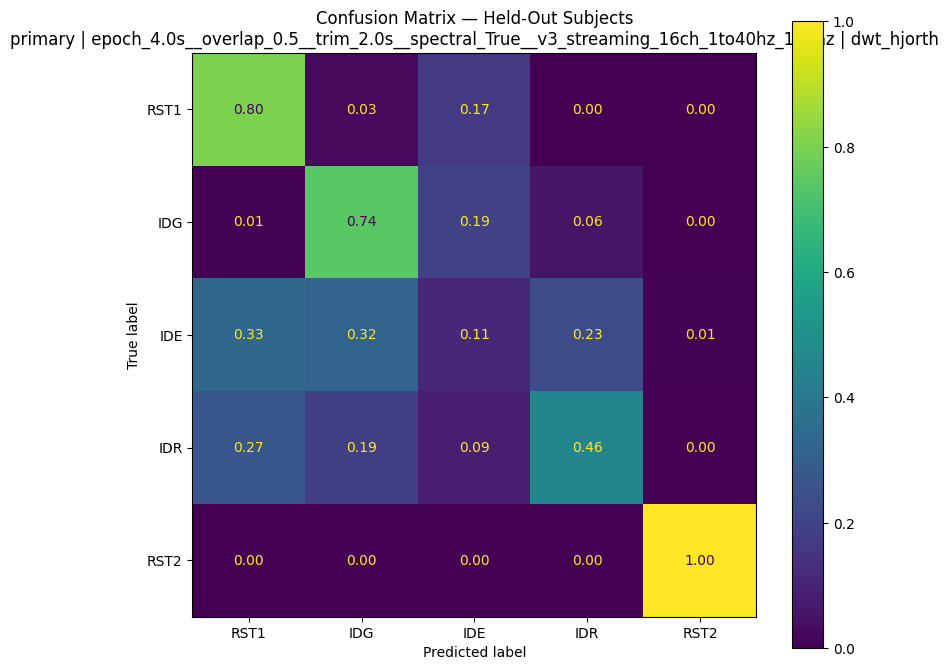

RECORD-LEVEL MAJORITY VOTE — HELD-OUT SUBJECTS
Accuracy: 0.5455
Bal Acc : 0.6667
Macro-F1: 0.5300


,source,subject_id,record_id,label,predicted_label
0,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDE1,IDE,RST1
1,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDE2,IDE,IDG
2,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDE3,IDE,IDR
3,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDG1,IDG,IDG
4,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDG2,IDG,IDG
5,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDG3,IDG,IDG
6,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDR1,IDR,RST1
7,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDR2,IDR,IDR
8,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_IDR3,IDR,IDG
9,primary,PRI_001,PRI_001__Primary_Creativity_Sub_1_RST1,RST1,RST1


In [ ]:
# ============================================================
# CONFUSION MATRIX & MAJORITY VOTE RECORD LEVEL
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(prediction_df["label"], prediction_df["predicted_label"], labels=LABELS, normalize="true", values_format=".2f", ax=ax)
ax.set_title(f"Confusion Matrix — Held-Out Subjects\n{DATASET_MODE} | {BEST_CONFIG_ID} | {BEST_SET}")
plt.tight_layout(); plt.show()

def majority_vote(series):
    modes = series.mode(); return sorted(modes.astype(str))[0] if not modes.empty else series.iloc[0]

record_prediction_df = prediction_df.groupby(["source", "subject_id", "record_id", "label"], as_index=False)["predicted_label"].agg(majority_vote)
print("RECORD-LEVEL MAJORITY VOTE — HELD-OUT SUBJECTS")
print(f"Accuracy: {accuracy_score(record_prediction_df['label'], record_prediction_df['predicted_label']):.4f}")
print(f"Bal Acc : {balanced_accuracy_score(record_prediction_df['label'], record_prediction_df['predicted_label']):.4f}")
print(f"Macro-F1: {f1_score(record_prediction_df['label'], record_prediction_df['predicted_label'], average='macro', zero_division=0):.4f}")
display(record_prediction_df.head(20)); record_prediction_df.to_csv(OUTPUT_DIR / f"record_predictions__{DATASET_MODE}.csv", index=False)

In [ ]:
# ============================================================
# FIT FINAL MODEL
# ============================================================
final_training_df = best_feature_df[best_feature_df["source"] == "secondary"].copy() if DATASET_MODE == "external_validation" else best_feature_df.copy()
X_final, y_final, groups_final = final_training_df[best_cols].values, final_training_df["label"].astype(str).values, final_training_df["group_id"].astype(str).values
unique_groups_final = np.unique(groups_final)

if len(unique_groups_final) >= 2:
    final_inner_cv = GroupKFold(n_splits=min(5, len(unique_groups_final)))
    final_search = GridSearchCV(estimator=make_knn_pipeline(), param_grid=PARAMETER_GRID, scoring="balanced_accuracy", cv=final_inner_cv, n_jobs=-1, refit=True)
    final_search.fit(X_final, y_final, groups=groups_final); final_model, final_best_params = final_search.best_estimator_, final_search.best_params_
else: final_model = make_fallback_pipeline(); final_model.fit(X_final, y_final); final_best_params = {"fallback": "KNN k=3"}

model_bundle = {"model": final_model, "best_params": final_best_params, "dataset_mode": DATASET_MODE, "best_config_id": BEST_CONFIG_ID, "best_feature_set": BEST_SET, "feature_columns": best_cols, "channels": CANONICAL_CHANNELS, "sampling_rate": FS_TARGET, "wavelet": WAVELET, "dwt_level": DWT_LEVEL}
model_path = OUTPUT_DIR / f"knn_model__{DATASET_MODE}.joblib"; joblib.dump(model_bundle, model_path)
print("BEST FINAL PARAMETERS:", final_best_params); print("MODEL TERSIMPAN DI:", model_path)

BEST FINAL PARAMETERS: {'fallback': 'KNN k=3'}
MODEL TERSIMPAN DI: /content/drive/MyDrive/Creativity-Dataset/output/knn_model__primary.joblib


In [ ]:
# ============================================================
# EXTERNAL VALIDATION (SECONDARY → PRIMARY)
# ============================================================
if DATASET_MODE != "external_validation": print("Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.")
else:
    ext_df = best_feature_df[best_feature_df["source"] == "primary"].copy()
    if ext_df.empty: raise ValueError("Dataset primer kosong. Pastikan file tersedia di folder Primary-raw.")
    X_ext, y_ext = ext_df[best_cols].values, ext_df["label"].astype(str).values; ext_preds = final_model.predict(X_ext)
    print("EXTERNAL VALIDATION: Train (Concordia) → Test (OpenBCI)")
    print(f"Accuracy: {accuracy_score(y_ext, ext_preds):.4f} | BalAcc: {balanced_accuracy_score(y_ext, ext_preds):.4f} | Macro-F1: {f1_score(y_ext, ext_preds, average='macro', zero_division=0):.4f}")
    print("\nCLASSIFICATION REPORT:\n", classification_report(y_ext, ext_preds, labels=LABELS, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7)); ConfusionMatrixDisplay.from_predictions(y_ext, ext_preds, labels=LABELS, normalize="true", values_format=".2f", ax=ax)
    ax.set_title("External Validation: Train Secondary → Test Primary"); plt.tight_layout(); plt.show()
    ext_res_df = ext_df[["source", "subject_id", "record_id", "label", "epoch_start"]].copy(); ext_res_df["predicted_label"] = ext_preds; ext_res_df.to_csv(OUTPUT_DIR / "external_validation_predictions.csv", index=False)

Cell external validation dilewati. Aktifkan DATASET_MODE = 'external_validation' pada Cell 1.
